# Project 1 — Decision Tree Regressor
## Used Car Price Prediction

Predicting the resale price of a used car from mileage, age, brand reputation score, and engine size.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 700
mileage = np.random.gamma(3, 20000, n)
age = np.random.randint(0, 20, n)
brand_score = np.random.uniform(1, 10, n)
engine_size = np.random.uniform(1.0, 5.0, n)

price = (35000 - 0.08*mileage - 900*age + 1200*brand_score + 1500*engine_size
         + np.random.normal(0, 1500, n)).clip(500, None)

df = pd.DataFrame({'mileage': mileage, 'age': age, 'brand_score': brand_score,
                    'engine_size': engine_size, 'price': price})
df.head()


,mileage,age,brand_score,engine_size,price
0,71256.373251,9,4.016872,3.626524,30920.078985
1,48943.887966,8,2.563854,1.961596,30355.168655
2,46045.611337,13,7.408126,1.766372,31431.411961
3,46046.097509,12,8.433804,4.672956,41685.861913
4,123322.798744,1,1.905737,1.407215,29156.583003


## 2. Preprocessing

In [3]:
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# No scaling needed for trees


## 3. Train Model

In [4]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=15, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 3027.277741756507
RMSE: 3713.701102298141
R2 Score: 0.7135104741679072


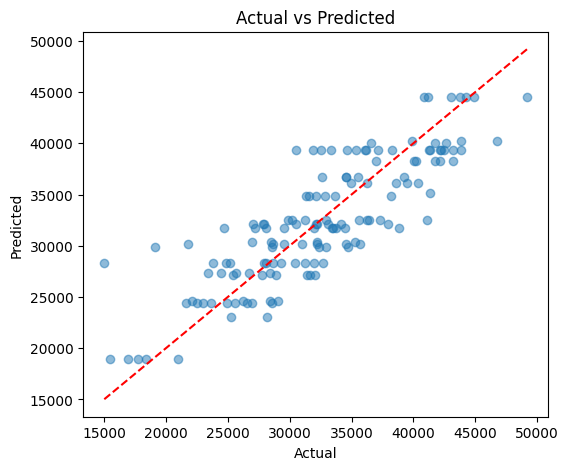

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Check `model.feature_importances_` — mileage and age should be the strongest predictors.
- Visualize with `plot_tree` to see the actual price-bucketing logic the tree learned.
- Next steps: compare `max_depth=5` vs `max_depth=None` (unrestricted) to directly see overfitting on train vs test MAE.

---
# Project 2 — Your Turn
**Dataset:** Geyser dataset (`seaborn.load_dataset('geyser')`) — predict `waiting` time between eruptions from eruption `duration` and `kind`.

```python
import seaborn as sns
geyser = sns.load_dataset('geyser')
```
**Tasks:** encode the `kind` column, train a Decision Tree Regressor, tune `max_depth`, evaluate with MAE/RMSE/R², and visualize the tree.
